# import bibliotek


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math

# Zadanie 2 i 3


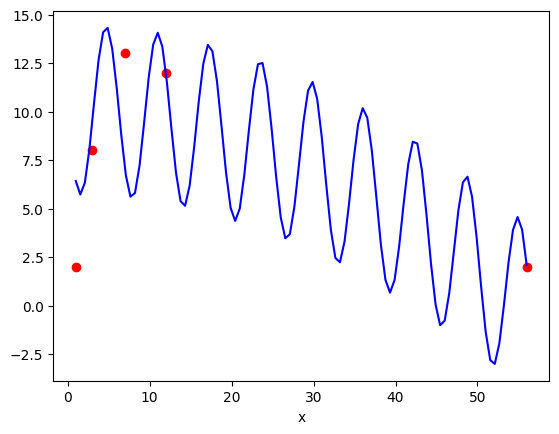

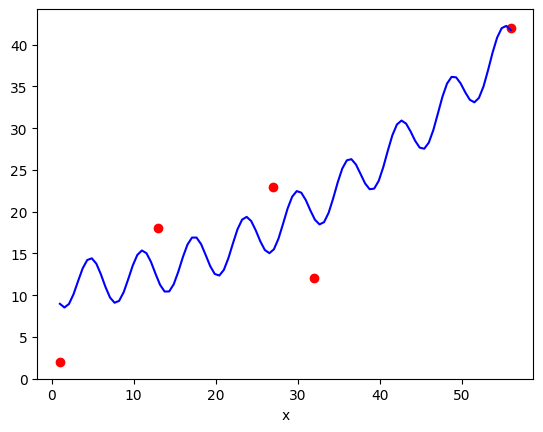

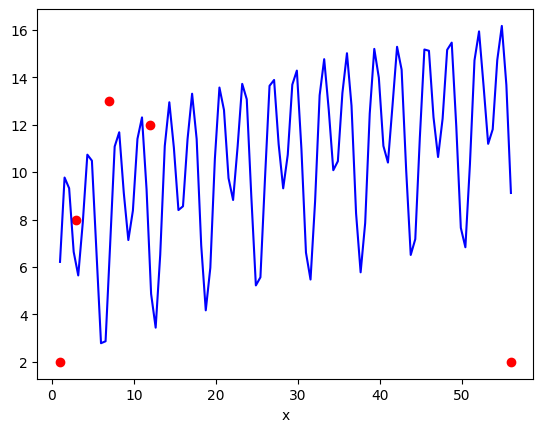

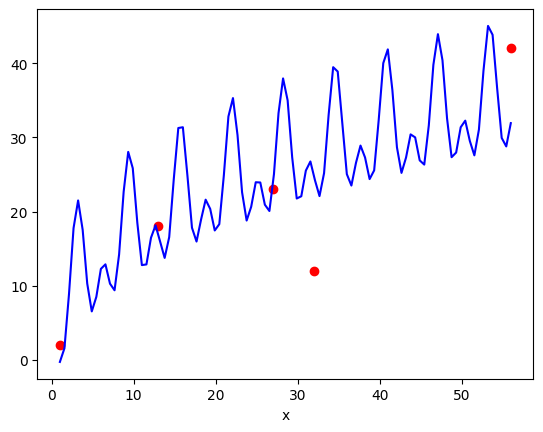

In [2]:
def MSElin(points, functionParams):
    # m = liczba punktów
    V = np.zeros((len(points), len(functionParams)))

    for i in range(len(points)):
        for idx, param in enumerate(functionParams):
            V[i][idx] = param(points[i][0])

    beta = np.linalg.inv(V.T @ V) @ V.T @ points[:, 1]
    return beta


points1 = np.array([(1, 2), (3, 8), (7, 13), (12, 12), (56, 2)], dtype=float)
points2 = np.array([(1, 2), (13, 18), (27, 23), (32, 12), (56, 42)], dtype=float)
functionParams1 = np.array(
    [lambda x: 1, lambda x: np.sin(x), lambda x: x**2]
)  # Zadanie 2
functionParams2 = np.array(
    [lambda x: np.sin(x) ** 2, lambda x: np.cos(x), lambda x: x ** (1 / 3)]
)  # zadanie 3

for points, functions in zip(
    [points1, points2, points1, points2],
    [functionParams1, functionParams1, functionParams2, functionParams2],
):
    plt.figure()
    beta = MSElin(points, functions)
    x = np.array(points)[:, 0]
    y = np.array(points)[:, 1]
    plt.scatter(x, y, color="red", label="Data Points")
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = sum(beta[i] * functions[i](x_fit) for i in range(len(functions)))
    plt.plot(x_fit, y_fit, color="blue", label="Fitted Curve")
    plt.xlabel("x")
    plt.show()


# Zadanie 4


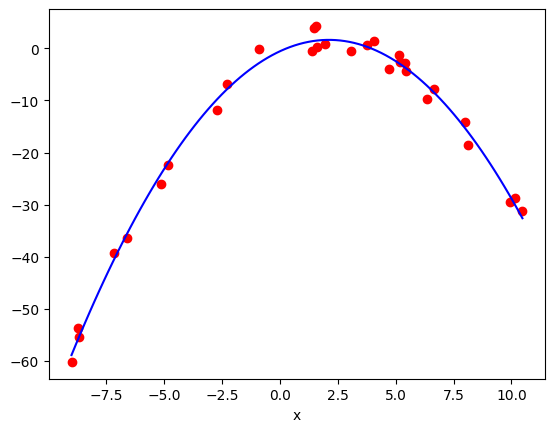

Uśrednione parametry funckji kwadratowej: [-0.50092708  1.99678156 -0.01925669]
około. -5x^2 + 2x + 0


In [54]:
liczbaIteracji = 200
betas = []
functionParams = np.array([lambda x: x**2, lambda x: x, lambda x: 1])

for iteration in range(liczbaIteracji):
    points = np.array(
        [
            (
                (x := np.random.uniform(-10, 10 + 1)),
                -0.5 * x**2 + 2 * x + np.random.uniform(-3, 3),
            )
            for _ in range(30)
        ],
        dtype=float,
    )

    beta = MSElin(points, functionParams)
    betas.append(beta)

    if iteration == liczbaIteracji - 1:
        plt.figure()
        x = points[:, 0]
        y = points[:, 1]
        plt.scatter(x, y, color="red", label="Data Points")
        x_fit = np.linspace(min(x), max(x), 100)
        y_fit = sum(
            beta[i] * functionParams[i](x_fit) for i in range(len(functionParams))
        )
        plt.plot(x_fit, y_fit, color="blue", label="Fitted Curve")
        plt.xlabel("x")
        plt.show()  # Pokazujemy tylko ostatnią iterację, funkcje są niemal identyczne

avg_beta = np.mean(np.array(betas), axis=0)
print("Uśrednione parametry funckji kwadratowej:", avg_beta)
print("około. -5x^2 + 2x + 0")
